In [6]:
source('lib/lib.R', chdir=T)
options(warn=-1)

In [7]:
cochlea <- readRDS('data/cyagen_scNym_clean.rds')

cell_levels <- levels(cochlea$scNym_refined)
cols <- setNames(
    scCustomize::DiscretePalette_scCustomize(num_colors=21, palette='ditto_seq', shuffle_pal=T, seed=15),
    cell_levels
)
cols[c('Ery', 'Ms', 'Is', 'Fb', 'EC', 'Peri')] <- c('#E31A1C', '#6A3D9A', '#CAB2D6', '#B2DF8A', '#7570B3', '#FB9A99')

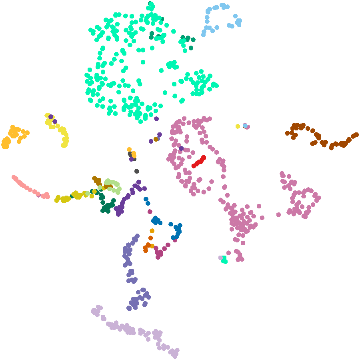

In [8]:
figs(3, 3)
umap(cochlea, reduction='rotated_umap', cluster='scNym_refined', dim=1:2, label=F, pt.size=1.2, color=cols) +
    guides(color=guide_legend(override.aes=list(size=3))) +
    scale_x_continuous(expand=c(0.01, 0)) +
    scale_y_continuous(expand=c(0.01, 0)) +
    theme_void() +
    theme(
        aspect.ratio=1,
        legend.position='none', legend.text=element_text(size=12)
    ) -> p

p <- rasterize(p, layers='Point', dpi=300)
p

In [41]:
run_deg <- function(subset, ident.1=NULL, ident.2=NULL){
    if(is.null(ident.1) & is.null(ident.2)){ error('Both ident.1 and ident.2 should not be NULL.') }
    FindMarkers(
        subset(cochlea, subset=scNym_refined %in% subset),
        group.by='orig.ident', ident.1=ident.1, ident.2=ident.2,
        only.pos=F, min.pct=0.01, logfc.threshold=0.01, test.use='roc'
    )
}

ct <- c('DC')
dc_deg <- list(
    'Rescued_Uninj' = run_deg(subset=ct, ident.1='Rescued', ident.2='Uninj'),
    'WT_Uninj'      = run_deg(subset=ct, ident.1='WT', ident.2='Uninj'),
    'Rescued_WT'    = run_deg(subset=ct, ident.1='Rescued', ident.2='WT')
) %>%
    lapply(function(df){
        df %>%
            rownames_to_column('gene') %>%
            filter(!grepl(pattern='^mt|^Rp[sl]', x=gene)) %>%
            arrange(-sign(avg_log2FC), desc(myAUC)) %>%
            mutate(
                sym_AUC = 2 * abs(myAUC - 0.5),
                score = sym_AUC * avg_log2FC
            )
    })

saveRDS(dc_deg, 'res/DC_roc_degs.rds')

In [9]:
dc_deg <- readRDS('res/DC_roc_degs.rds')

In [16]:
suppressMessages(library(msigdbr))

stat <- dc_deg$WT_Uninj %>%
    filter(pmin(pct.1, pct.2) > 0.01, score != 0) %>%
    arrange(-score) %>% select(gene, score) %>%
    tibble::deframe()

m_t2g <- msigdbr(species='Mus musculus', subcollection='GO:BP') %>%
    dplyr::select(gs_exact_source, gene_symbol, gs_name)

gene_sets_bp <- m_t2g %>%
    group_by(gs_name) %>%
    summarise(genes = list(gene_symbol)) %>%
    deframe()

gene_sets_bp$scTenifold <- scan(text='Mpzl2 Gm13782 Smagp Uchl1 Cep41 Acot1 Aqp11 Slc1a3 Ttll3 Slc44a2 Col9a2 Malat1 Tuba1a Gjb6 Fibin 6330411D24Rik Pim1 9130008F23Rik Ogt Col9a1 Cpa6 Gm37108 Tbx2 Dync1i1 Tectb Gpc2 Neat1 Dynlt1a Chadl Tmod2 Gpatch8 Itih5 Auts2 Klf5 Trpm3 Gdpd1 Far1 Tesc Fbxo32 Slc38a2 Tmem86a Slc4a4 Errfi1 Col2a1 Klf10 Paqr8 Rasd1 Zbtb20 Bdnf Fos Gm2830 Amer2 Ceacam16 Kazald1 Plcd3 Cldn3 Scd1 Elovl1 Fosb Slc20a1 Ikzf2 Enah Slc12a7 Tmem117 Fgfr3 Gm37376 Lox Tcf4 Clk1 Kcnj16 Pnisr Gm42826 Aopep Wls Tspan8 Ehd3 Grb14 Fkbp1a Akap12 Rbm5 Myo10 Il1rapl1 Tesk2 Nceh1 Pcolce2 Klf9 Gm15536 Lpin2 Sapcd2 Jun Fut8 Dpysl2 Serpinh1 Gm13436 Grk3 Stmn1 S100b Dusp1 Kitl', what='')

In [70]:
suppressMessages(library(fgsea))

gobp_res <- fgseaMultilevel(
    pathways = gene_sets_bp,
    stats = stat,
    scoreType = 'pos',
    minSize = 15,
    maxSize = 300,
    nPermSimple = 10000
)

saveRDS(gobp_res, 'res/WT_uninj_fgsea_gobp.rds')

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (51.56% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


In [18]:
gobp_res <- readRDS('res/WT_Uninj_fgsea_gobp.rds')
gobp_res_clean <- gobp_res %>%
    filter(padj < 0.05, pathway != 'scTenifold') %>%
    mutate(
        pathway_clean = pathway %>%
            str_remove('^GOBP_') %>%
            str_replace_all('_', ' ') %>%
            str_to_sentence() %>%
            str_replace('mrna', 'mRNA') %>%
            str_replace('rna polymerase ii', 'RNA polymerase II')
    )

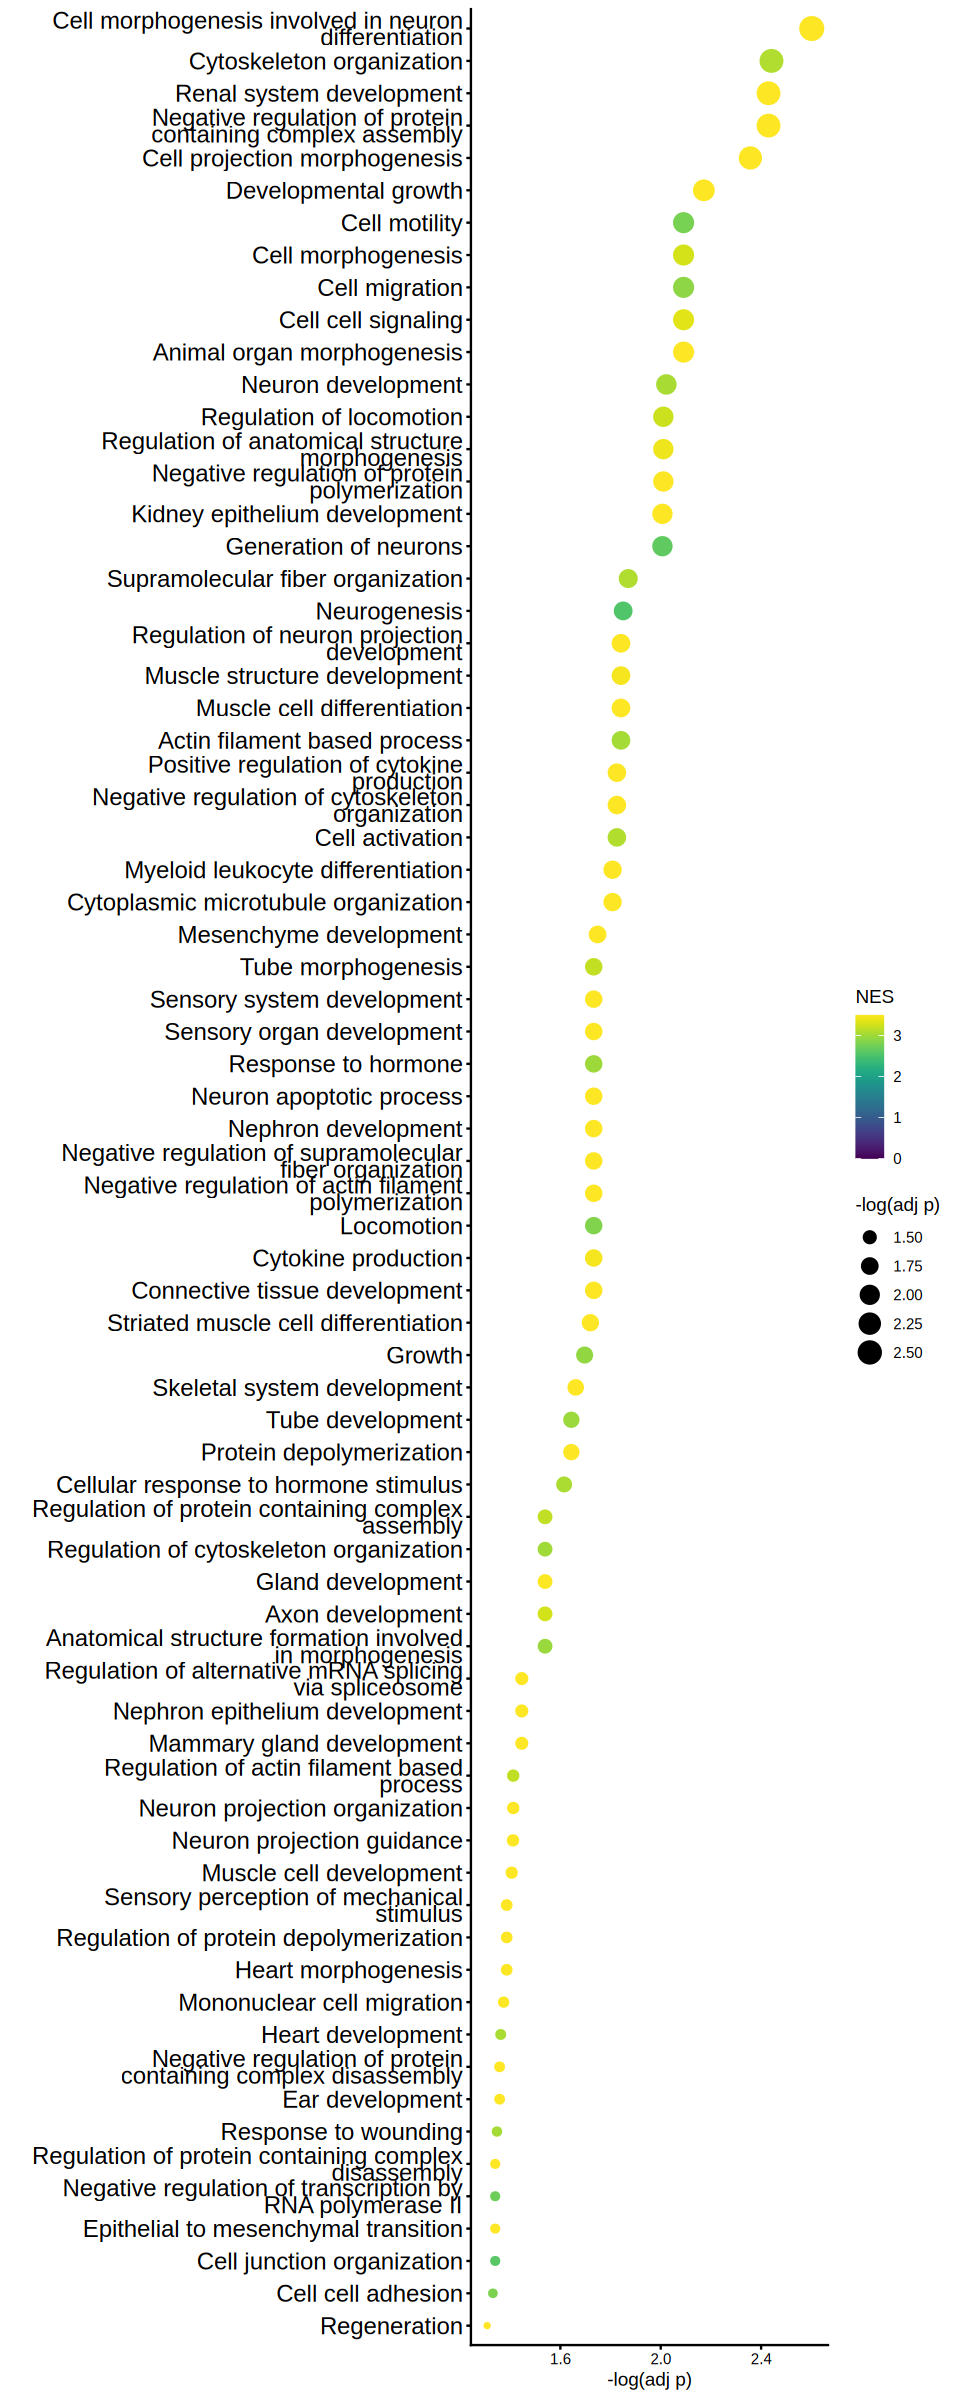

In [23]:
figs(20, 8)
gobp_res_clean %>%
    filter(padj < 0.05) %>%
    arrange(padj) %>%
    mutate(
        pathway_clean = pathway_clean %>% str_wrap(width = 40),
        .after = 1
    ) %>%
    mutate(
        score = -log10(padj),
        pathway_clean = forcats::fct_reorder(pathway_clean, score)
    ) %>%
    ggplot(aes(x = score, y = pathway_clean)) +
    geom_point(aes(color = NES, size = score)) +
    scale_color_viridis(limits=c(0, 3.5), oob=scales::oob_squish) +
    labs(
        x = '-log(adj p)',
        y = NULL,
        color = 'NES',
        size = '-log(adj p)'
    ) +
    theme_classic() +
    theme(
        axis.text.y = element_text(size=14, lineheight=0.6, color = 'black'),
        axis.text.x = element_text(color = 'black')
    ) -> p

p

In [24]:
plot_custom_gsea <- function(gsoi_id, gsoi_name, gene_sets, stat, n_labels = 10) {
    library(dplyr)
    library(ggplot2)
    library(ggrepel)
    library(patchwork)
    
    pd <- fgsea::plotEnrichmentData(gene_sets[[gsoi_id]], stats = stat)
    
    peak_rank <- pd$curve %>%
        dplyr::filter(ES == max(ES)) %>%
        dplyr::pull(rank) %>%
        min()
    
    ordered_genes <- names(sort(stat, decreasing = TRUE))
    gene_ranks <- data.frame(
        gene = ordered_genes,
        rank = seq_along(ordered_genes)
    )
    
    # Leading edge genes
    le_label_data <- gene_ranks %>%
        dplyr::filter(gene %in% gene_sets[[gsoi_id]]) %>%
        dplyr::filter(rank <= peak_rank) %>%
        dplyr::inner_join(pd$curve, by = 'rank') %>%
        dplyr::distinct(gene, .keep_all = TRUE) %>%
        head(n_labels)
    
    # Enrichment Score (ES) curve
    p_es <- ggplot(pd$curve, aes(x = rank, y = ES)) +
        geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey70') +
        geom_line(color = '#4daf4a', linewidth = 0.6) +
        geom_text_repel(
            data = le_label_data,
            aes(label = gene),
            nudge_y = 0.05,
            nudge_x = 100,
            segment.color = 'grey50',
            segment.size = 0.3,
            size = 3,
            min.segment.length = 0,
            max.overlaps = Inf
        ) +
        labs(x = NULL, y = 'ES', title = gsoi_name) +
        scale_x_continuous(expand = c(0, 0)) +
        theme_classic() +
        theme(
            axis.text.x = element_blank(),
            axis.ticks.x = element_blank(),
            axis.line.x = element_blank(),
            plot.margin = margin(b = 0, unit = 'pt'),
            plot.title = element_text(size = 12, margin = margin(l = -6, b = 2, unit = 'mm'))
        )
    
    # Leading edge ticks
    p_ticks <- ggplot(pd$ticks, aes(x = rank)) +
        geom_segment(aes(xend = rank, y = 0, yend = 1), linewidth = 0.1) +
        scale_x_continuous(expand = c(0, 0)) +
        scale_y_continuous(expand = c(0, 0)) +
        theme_void() +
        theme(plot.margin = margin(t = 0, b = 0, unit = 'pt'))
    
    # Diverging color bar
    max_stat <- max(pd$stats$stat, na.rm = TRUE)
    min_stat <- min(pd$stats$stat, na.rm = TRUE)
    color_breaks <- scales::rescale(c(min_stat, -0.5, 0, 0.5, max_stat))
    
    p_color <- ggplot(pd$stats, aes(x = rank, y = 1, fill = stat)) +
        geom_tile() +
        scale_fill_gradientn(
            colors = c('blue', 'dodgerblue', 'white', 'indianred', 'red'),
            values = color_breaks,
            guide = 'none'
        ) +
        scale_x_continuous(expand = c(0, 0)) +
        scale_y_continuous(expand = c(0, 0)) +
        theme_void() +
        theme(plot.margin = margin(t = 0, b = 0, unit = 'pt'))
    
    # Ranked metric distribution
    stat_limit <- abs(pmin(min_stat, max_stat))
    p_stat <- ggplot(pd$stats, aes(x = rank, y = stat)) +
        geom_area(fill = 'grey60') +
        geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey70') +
        labs(x = 'Rank in Ordered Dataset', y = 'Score') +
        scale_x_continuous(expand = c(0, 0)) +
        scale_y_continuous(limits = c(-stat_limit, stat_limit)) +
        theme_classic() +
        theme(plot.margin = margin(t = 0, unit = 'pt'))

    #
    final_plot <- p_es / p_ticks / p_color / p_stat + 
        plot_layout(heights = c(1.5, 0.25, 0.1, 1))
    
    return(final_plot)
}

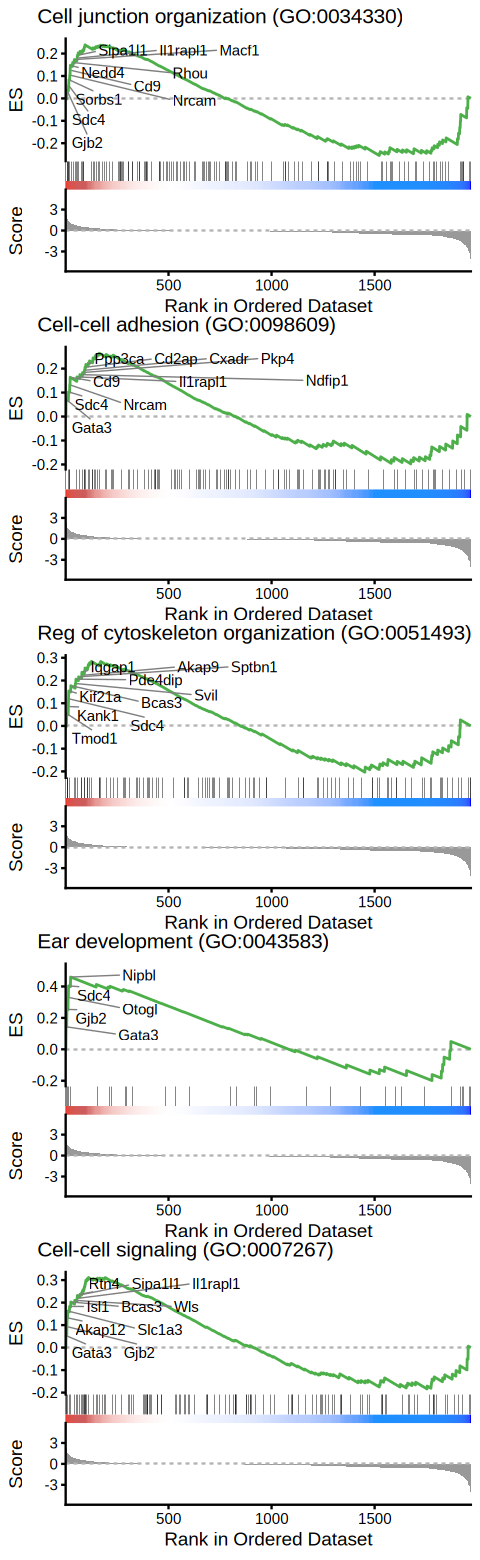

In [28]:
gsoi_list <- list(
    'Cell junction organization (GO:0034330)'='GOBP_CELL_JUNCTION_ORGANIZATION',
    'Cell-cell adhesion (GO:0098609)'='GOBP_CELL_CELL_ADHESION',
    'Reg of cytoskeleton organization (GO:0051493)'='GOBP_REGULATION_OF_CYTOSKELETON_ORGANIZATION',
    'Ear development (GO:0043583)'='GOBP_EAR_DEVELOPMENT',
    'Cell-cell signaling (GO:0007267)'='GOBP_CELL_CELL_SIGNALING'
)

p_list <- lapply(seq_along(gsoi_list), function(i){
    plot_custom_gsea(
        gsoi_id   = gsoi_list[[i]],
        gsoi_name = names(gsoi_list)[[i]],
        gene_sets = gene_sets_bp,
        stat      = stat,
        n_labels  = 10
    )
})

figs(13, 4)
wrap_plots(p_list, ncol=1)